# Separación de background y perturbación en datos sintéticos VLF

Este notebook:

- carga una señal sintética VLF (`A_syn`, `phi_syn`) junto con sus componentes **true**
  (`A_bg`, `phi_bg`, `A_pert_true`, `phi_pert_true`);
- ajusta la señal total con **background polinómico + perturbación F3**;
- evalúa los grados de background en `BG_DEGREES`;
- calcula una métrica de desempeño consistente con la *loss* de inversión:
  **χ² normalizado**;
- usa como **target** a los componentes **true** del caso sintético:
  - `true background` para evaluar la separación del background,
  - `true perturbation` para evaluar la separación de la perturbación;
- resume los resultados en tablas y en una figura principal **2×2**.

## Definición usada de χ² normalizado

Para un modelo `model` y un target `true`:

$$
\chi^2_{\mathrm{norm}}(\mathrm{model}, \mathrm{true})
=
\frac{
\sum_i \left(\mathrm{model}_i - \mathrm{true}_i\right)^2
}{
\sum_i \left(\mathrm{true}_i - \overline{\mathrm{true}}\right)^2 + 10^{-12}
}
$$

Luego se combinan amplitud y fase.

Para el **background**:

$$
\chi^2_{\mathrm{norm,bg}}
=
\chi^2_{\mathrm{norm}}
\left(
A_{\mathrm{bg,fit}},
A_{\mathrm{bg,true}}
\right)
+
\chi^2_{\mathrm{norm}}
\left(
\phi_{\mathrm{bg,fit}},
\phi_{\mathrm{bg,true}}
\right)
$$

Para la **perturbación**:

$$
\chi^2_{\mathrm{norm,pert}}
=
\chi^2_{\mathrm{norm}}
\left(
A_{\mathrm{pert,fit}},
A_{\mathrm{pert,true}}
\right)
+
\chi^2_{\mathrm{norm}}
\left(
\phi_{\mathrm{pert,fit}},
\phi_{\mathrm{pert,true}}
\right)
$$

**Nota:** esta cantidad no es el `redchi` de `lmfit`; aquí se usa la versión normalizada que es consistente con la función de pérdida de tus inversiones.

In [1]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from lmfit import Model, Parameters

# ============================================================
# CONFIG
# ============================================================
filename = "synthetic_F3_nexp_seed_fine2.h5"
BG_DEGREES = (3, 4, 5, 6, 7)
EPS_NORM = 1e-12
MAX_NFEV = 30000

DATE_FORMAT = "%H:%M"
PLOT_STYLE = {
    "lw_signal": 2.4,
    "lw_true": 2.4,
    "lw_fit": 2.0,
    "alpha_grid": 0.30,
    "figsize_main": (17, 10),
    "figsize_rank": (12, 4.5),
}

if not Path(filename).is_file():
    raise FileNotFoundError(
        f"No se encontró '{filename}'. Coloca el archivo H5 en el mismo directorio que este notebook."
    )

# ============================================================
# DATA LOADING
# ============================================================
def _decode_if_needed(x):
    if isinstance(x, bytes):
        return x.decode("utf-8", errors="replace")
    if isinstance(x, np.ndarray) and x.shape == () and isinstance(x.item(), bytes):
        return x.item().decode("utf-8", errors="replace")
    return x

with h5py.File(filename, "r") as f:
    data = {k: f[k][()] for k in f.keys()}
    attrs = {k: _decode_if_needed(v) for k, v in f.attrs.items()}

required = ["timestamps", "A_bg", "phi_bg", "A_syn", "phi_syn"]
missing = [k for k in required if k not in data]
if missing:
    raise KeyError(f"Faltan datasets obligatorios en el archivo: {missing}")

timestamps = np.asarray(data["timestamps"], dtype=float)
A_bg_true  = np.asarray(data["A_bg"], dtype=float)
phi_bg_true = np.asarray(data["phi_bg"], dtype=float)
A_syn      = np.asarray(data["A_syn"], dtype=float)
phi_syn    = np.asarray(data["phi_syn"], dtype=float)

time_utc = pd.to_datetime(timestamps, unit="s", utc=True).tz_convert("UTC").tz_localize(None)
t_hours = (time_utc - time_utc[0]).total_seconds().to_numpy() / 3600.0

A_pert_true = A_syn - A_bg_true
phi_pert_true = phi_syn - phi_bg_true

model_attr = attrs.get("model", "")
note_attr  = attrs.get("note", "")

print("Datasets disponibles:", sorted(data.keys()))
print("Atributos disponibles:", sorted(attrs.keys()))
print("\nmodel =", model_attr)
print("note  =", note_attr)
print("\nGrados de background evaluados:", BG_DEGREES)
print("Número de muestras:", len(timestamps))
print("Rango temporal UTC:", time_utc[0], "->", time_utc[-1])

# ============================================================
# CORE MODELS
# ============================================================
def poly_bg(t, coeffs):
    return np.polynomial.polynomial.polyval(np.asarray(t, dtype=float), coeffs)

def delta_form3(t, t_pk, amp, tau_u, tau_d, eps):
    t = np.asarray(t, dtype=float)
    tau_u = max(float(tau_u), 1e-9)
    tau_d = max(float(tau_d), 1e-9)
    eps   = max(float(eps),   1e-9)

    width = tau_u + 0.5 * (tau_d - tau_u) * (1.0 + np.tanh((t - t_pk) / eps))
    width = np.maximum(width, 1e-9)
    return amp * np.exp(-0.5 * ((t - t_pk) / width) ** 2)

def build_f3_model(deg):
    coeff_names = [f"a{i}" for i in range(deg + 1)]
    arg_list = ", ".join(["t"] + coeff_names + ["amp", "t_pk", "tau_u", "tau_d", "eps"])
    coeff_expr = ", ".join(coeff_names)
    body = (
        f"def f3_deg{deg}({arg_list}):\n"
        f"    coeffs = [{coeff_expr}]\n"
        f"    return poly_bg(t, coeffs) + delta_form3(t, t_pk, amp, tau_u, tau_d, eps)"
    )
    namespace = {"poly_bg": poly_bg, "delta_form3": delta_form3}
    exec(body, namespace)
    return Model(namespace[f"f3_deg{deg}"])

MODEL_BY_DEG = {deg: build_f3_model(deg) for deg in BG_DEGREES}

# ============================================================
# METRICS
# ============================================================
def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rss = np.sum((y_true - y_pred) ** 2)
    tss = np.sum((y_true - np.mean(y_true)) ** 2)
    return np.nan if tss <= 0 else 1.0 - rss / tss

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))

def bias(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(y_pred - y_true)

def normalized_chi2_1d(model, true, eps=EPS_NORM):
    model = np.asarray(model, dtype=float)
    true = np.asarray(true, dtype=float)
    scale = np.sum((true - np.mean(true)) ** 2) + eps
    return np.sum((model - true) ** 2) / scale

def normalized_chi2_2ch(model_A, true_A, model_phi, true_phi, eps=EPS_NORM):
    return (
        normalized_chi2_1d(model_A, true_A, eps=eps)
        + normalized_chi2_1d(model_phi, true_phi, eps=eps)
    )

# ============================================================
# INITIALIZATION
# ============================================================
def init_poly_coeffs(deg, t_fit, y_fit):
    n = len(t_fit)
    edge_n = min(max(8, n // 10), max(8, n // 2))
    edge_idx = np.r_[0:edge_n, n-edge_n:n]
    coeff_desc = np.polyfit(t_fit[edge_idx], y_fit[edge_idx], deg)
    return coeff_desc[::-1]

def build_params_for_f3(deg, t_fit, y_fit):
    coeffs0 = init_poly_coeffs(deg, t_fit, y_fit)
    bg0 = poly_bg(t_fit, coeffs0)
    resid0 = y_fit - bg0

    i0 = int(np.argmax(np.abs(resid0)))
    t_pk0 = float(t_fit[i0])
    amp0  = float(resid0[i0])

    dt_step = float(np.median(np.diff(t_fit))) if len(t_fit) > 1 else 1.0
    t_span  = float(t_fit.max() - t_fit.min()) if len(t_fit) > 1 else 1.0
    y_range = float(np.ptp(y_fit))
    amp_ref = max(abs(amp0), y_range, 1.0)

    pars = Parameters()
    for i, c in enumerate(coeffs0):
        pars.add(f"a{i}", value=float(c))

    pars.add("amp",   value=amp0, min=-10.0 * amp_ref, max=10.0 * amp_ref)
    pars.add("t_pk",  value=t_pk0, min=float(t_fit.min()), max=float(t_fit.max()))
    pars.add("tau_u", value=max(3.0 * dt_step, 0.03 * t_span),
             min=max(dt_step / 10.0, 1e-6), max=max(2.0 * t_span, dt_step))
    pars.add("tau_d", value=max(6.0 * dt_step, 0.06 * t_span),
             min=max(dt_step / 10.0, 1e-6), max=max(2.0 * t_span, dt_step))
    pars.add("eps",   value=max(2.0 * dt_step, 0.02 * t_span),
             min=max(dt_step / 10.0, 1e-6), max=max(t_span, dt_step))
    return pars

# ============================================================
# FIT HELPERS
# ============================================================
def fit_channel(y_fit, t_fit, time_utc, channel_name, degrees=BG_DEGREES, max_nfev=MAX_NFEV):
    y_fit = np.asarray(y_fit, dtype=float)
    fit_results = {}

    for deg in degrees:
        model = MODEL_BY_DEG[deg]
        pars = build_params_for_f3(deg, t_fit, y_fit)
        res = model.fit(y_fit, pars, t=t_fit, nan_policy="omit", max_nfev=max_nfev)

        coeffs = np.array([res.params[f"a{i}"].value for i in range(deg + 1)], dtype=float)
        amp    = float(res.params["amp"].value)
        t_pk   = float(res.params["t_pk"].value)
        tau_u  = float(res.params["tau_u"].value)
        tau_d  = float(res.params["tau_d"].value)
        eps    = float(res.params["eps"].value)

        background = poly_bg(t_fit, coeffs)
        perturbation = delta_form3(t_fit, t_pk, amp, tau_u, tau_d, eps)
        total_fit = background + perturbation

        fit_results[deg] = {
            "channel": channel_name,
            "degree": deg,
            "time_utc": time_utc.copy(),
            "t_hours": np.asarray(t_fit, dtype=float).copy(),
            "data": y_fit.copy(),
            "background": background,
            "perturbation": perturbation,
            "total_fit": total_fit,
            "residual": y_fit - total_fit,
            "params": {
                **{f"a{i}": coeffs[i] for i in range(deg + 1)},
                "amp": amp,
                "t_pk": t_pk,
                "tau_u": tau_u,
                "tau_d": tau_d,
                "eps": eps,
            },
            "fit_stats": {
                "redchi": float(res.redchi),
                "aic": float(res.aic),
                "bic": float(res.bic),
                "r2_total": float(r2_score(y_fit, total_fit)),
                "nfev": int(getattr(res, "nfev", np.nan)),
            },
            "lmfit_result": res,
        }

    return fit_results

A_results = fit_channel(A_syn, t_hours, time_utc, channel_name="Amplitude")
phi_results = fit_channel(phi_syn, t_hours, time_utc, channel_name="Phase")

# ============================================================
# MERGE CHANNEL RESULTS + COMPONENT METRICS AGAINST TRUE
# ============================================================
results_by_degree = {}

for deg in BG_DEGREES:
    Ares = A_results[deg]
    Pres = phi_results[deg]

    chi2norm_bg = normalized_chi2_2ch(
        Ares["background"], A_bg_true,
        Pres["background"], phi_bg_true,
    )
    chi2norm_pert = normalized_chi2_2ch(
        Ares["perturbation"], A_pert_true,
        Pres["perturbation"], phi_pert_true,
    )

    results_by_degree[deg] = {
        "degree": deg,
        "A": Ares,
        "phi": Pres,
        "chi2norm_bg": float(chi2norm_bg),
        "chi2norm_pert": float(chi2norm_pert),
        "component_metrics": {
            "A_bg": {
                "rmse": float(rmse(A_bg_true, Ares["background"])),
                "mae": float(mae(A_bg_true, Ares["background"])),
                "bias": float(bias(A_bg_true, Ares["background"])),
                "r2": float(r2_score(A_bg_true, Ares["background"])),
            },
            "phi_bg": {
                "rmse": float(rmse(phi_bg_true, Pres["background"])),
                "mae": float(mae(phi_bg_true, Pres["background"])),
                "bias": float(bias(phi_bg_true, Pres["background"])),
                "r2": float(r2_score(phi_bg_true, Pres["background"])),
            },
            "A_pert": {
                "rmse": float(rmse(A_pert_true, Ares["perturbation"])),
                "mae": float(mae(A_pert_true, Ares["perturbation"])),
                "bias": float(bias(A_pert_true, Ares["perturbation"])),
                "r2": float(r2_score(A_pert_true, Ares["perturbation"])),
            },
            "phi_pert": {
                "rmse": float(rmse(phi_pert_true, Pres["perturbation"])),
                "mae": float(mae(phi_pert_true, Pres["perturbation"])),
                "bias": float(bias(phi_pert_true, Pres["perturbation"])),
                "r2": float(r2_score(phi_pert_true, Pres["perturbation"])),
            },
        },
    }

fit_rows = []
component_rows = []

for deg, res in results_by_degree.items():
    fit_rows.append({
        "degree": deg,
        "redchi_A": res["A"]["fit_stats"]["redchi"],
        "aic_A": res["A"]["fit_stats"]["aic"],
        "bic_A": res["A"]["fit_stats"]["bic"],
        "r2_total_A": res["A"]["fit_stats"]["r2_total"],
        "redchi_phi": res["phi"]["fit_stats"]["redchi"],
        "aic_phi": res["phi"]["fit_stats"]["aic"],
        "bic_phi": res["phi"]["fit_stats"]["bic"],
        "r2_total_phi": res["phi"]["fit_stats"]["r2_total"],
        "chi2norm_bg": res["chi2norm_bg"],
        "chi2norm_pert": res["chi2norm_pert"],
    })

    component_rows.append({
        "degree": deg,
        "chi2norm_bg": res["chi2norm_bg"],
        "chi2norm_pert": res["chi2norm_pert"],
        "rmse_A_bg": res["component_metrics"]["A_bg"]["rmse"],
        "mae_A_bg": res["component_metrics"]["A_bg"]["mae"],
        "bias_A_bg": res["component_metrics"]["A_bg"]["bias"],
        "r2_A_bg": res["component_metrics"]["A_bg"]["r2"],
        "rmse_phi_bg": res["component_metrics"]["phi_bg"]["rmse"],
        "mae_phi_bg": res["component_metrics"]["phi_bg"]["mae"],
        "bias_phi_bg": res["component_metrics"]["phi_bg"]["bias"],
        "r2_phi_bg": res["component_metrics"]["phi_bg"]["r2"],
        "rmse_A_pert": res["component_metrics"]["A_pert"]["rmse"],
        "mae_A_pert": res["component_metrics"]["A_pert"]["mae"],
        "bias_A_pert": res["component_metrics"]["A_pert"]["bias"],
        "r2_A_pert": res["component_metrics"]["A_pert"]["r2"],
        "rmse_phi_pert": res["component_metrics"]["phi_pert"]["rmse"],
        "mae_phi_pert": res["component_metrics"]["phi_pert"]["mae"],
        "bias_phi_pert": res["component_metrics"]["phi_pert"]["bias"],
        "r2_phi_pert": res["component_metrics"]["phi_pert"]["r2"],
    })

fit_summary = pd.DataFrame(fit_rows).sort_values("degree").reset_index(drop=True)
component_summary = pd.DataFrame(component_rows).sort_values("degree").reset_index(drop=True)

best_degree_bg = int(component_summary.loc[component_summary["chi2norm_bg"].idxmin(), "degree"])
best_degree_pert = int(component_summary.loc[component_summary["chi2norm_pert"].idxmin(), "degree"])
best_degree_aic_A = int(fit_summary.loc[fit_summary["aic_A"].idxmin(), "degree"])
best_degree_aic_phi = int(fit_summary.loc[fit_summary["aic_phi"].idxmin(), "degree"])

print(f"Best degree by chi2norm_bg   : {best_degree_bg}")
print(f"Best degree by chi2norm_pert : {best_degree_pert}")
print(f"Best degree by AIC (A)       : {best_degree_aic_A}")
print(f"Best degree by AIC (phi)     : {best_degree_aic_phi}")

# ============================================================
# CONVENIENCE STRUCTURES
# ============================================================
truth = {
    "A": {
        "full_signal": A_syn.copy(),
        "background": A_bg_true.copy(),
        "perturbation": A_pert_true.copy(),
    },
    "phi": {
        "full_signal": phi_syn.copy(),
        "background": phi_bg_true.copy(),
        "perturbation": phi_pert_true.copy(),
    },
    "time_utc": time_utc.copy(),
    "t_hours": t_hours.copy(),
}


Datasets disponibles: ['A_bg', 'A_syn', 'coeffs_beta_alb', 'coeffs_h_alb', 'pars_syn', 'phi_bg', 'phi_syn', 'target_A_corr', 'target_A_raw', 'target_phi_corr', 'target_phi_raw', 'timestamps']
Atributos disponibles: ['model', 'note']

model = F3_gaussiana_asimetrica_nexp_vertical
note  = Serie sintética perturbada y serie background generadas con el mismo background ionosférico del script real

Grados de background evaluados: (3, 4, 5, 6, 7)
Número de muestras: 241
Rango temporal UTC: 2008-03-25 18:00:00 -> 2008-03-25 22:00:00
Best degree by chi2norm_bg   : 4
Best degree by chi2norm_pert : 4
Best degree by AIC (A)       : 7
Best degree by AIC (phi)     : 7



## Tablas de resumen

- `fit_summary`: métricas del ajuste total por canal (`redchi`, `AIC`, `BIC`, `R²`) + `chi2norm_bg` y `chi2norm_pert`.
- `component_summary`: métricas contra los componentes **true** para background y perturbation.
- `results_by_degree[deg]`: estructura completa por grado.
- `best_degree_bg`: mejor grado por `chi2norm_bg`.
- `best_degree_pert`: mejor grado por `chi2norm_pert`.


In [2]:

print("=== FIT SUMMARY ===")
display(fit_summary.round(6))

print("\n=== COMPONENT SUMMARY VS TRUE ===")
display(component_summary.round(6))


=== FIT SUMMARY ===


,degree,redchi_A,aic_A,bic_A,r2_total_A,redchi_phi,aic_phi,bic_phi,r2_total_phi,chi2norm_bg,chi2norm_pert
0,3,0.002977,-1393.025759,-1361.662587,0.998813,0.617203,-107.468759,-76.105587,0.999422,0.006139,0.008552
1,4,0.000664,-1753.629871,-1718.781902,0.999736,0.363831,-233.880480,-199.032510,0.999661,0.002331,0.006045
2,5,0.000091,-2230.979946,-2192.647180,0.999964,0.228428,-345.103875,-306.771109,0.999788,0.005168,0.011050
3,6,0.000088,-2239.092416,-2197.274853,0.999965,0.221966,-351.069472,-309.251909,0.999795,0.004439,0.009633
4,7,0.000061,-2324.666811,-2279.364451,0.999976,0.206008,-368.105385,-322.803025,0.999810,0.007694,0.015510



=== COMPONENT SUMMARY VS TRUE ===


,degree,chi2norm_bg,chi2norm_pert,rmse_A_bg,mae_A_bg,bias_A_bg,r2_A_bg,rmse_phi_bg,mae_phi_bg,bias_phi_bg,r2_phi_bg,rmse_A_pert,mae_A_pert,bias_A_pert,r2_A_pert,rmse_phi_pert,mae_phi_pert,bias_phi_pert,r2_phi_pert
0,3,0.006139,0.008552,0.071895,0.056238,-0.032934,0.995403,0.865788,0.726357,-0.268635,0.998458,0.063395,0.033908,0.032934,0.993903,0.768962,0.407619,0.268635,0.997545
1,4,0.002331,0.006045,0.047035,0.035966,-0.032749,0.998033,0.420287,0.369514,-0.234044,0.999637,0.053557,0.034238,0.032749,0.995649,0.638725,0.384084,0.234044,0.998306
2,5,0.005168,0.011050,0.039693,0.028275,-0.025525,0.998599,1.353223,0.948111,-0.885414,0.996233,0.040553,0.026543,0.025525,0.997505,1.435581,0.897013,0.885773,0.991445
3,6,0.004439,0.009633,0.033859,0.024406,-0.021807,0.998980,1.289292,0.913997,-0.836606,0.996581,0.034856,0.022842,0.021807,0.998157,1.369853,0.849358,0.837370,0.992210
4,7,0.007694,0.015510,0.058023,0.037973,-0.035644,0.997006,1.511618,1.014183,-0.958869,0.995300,0.058401,0.036636,0.035644,0.994826,1.577884,0.972850,0.958899,0.989665


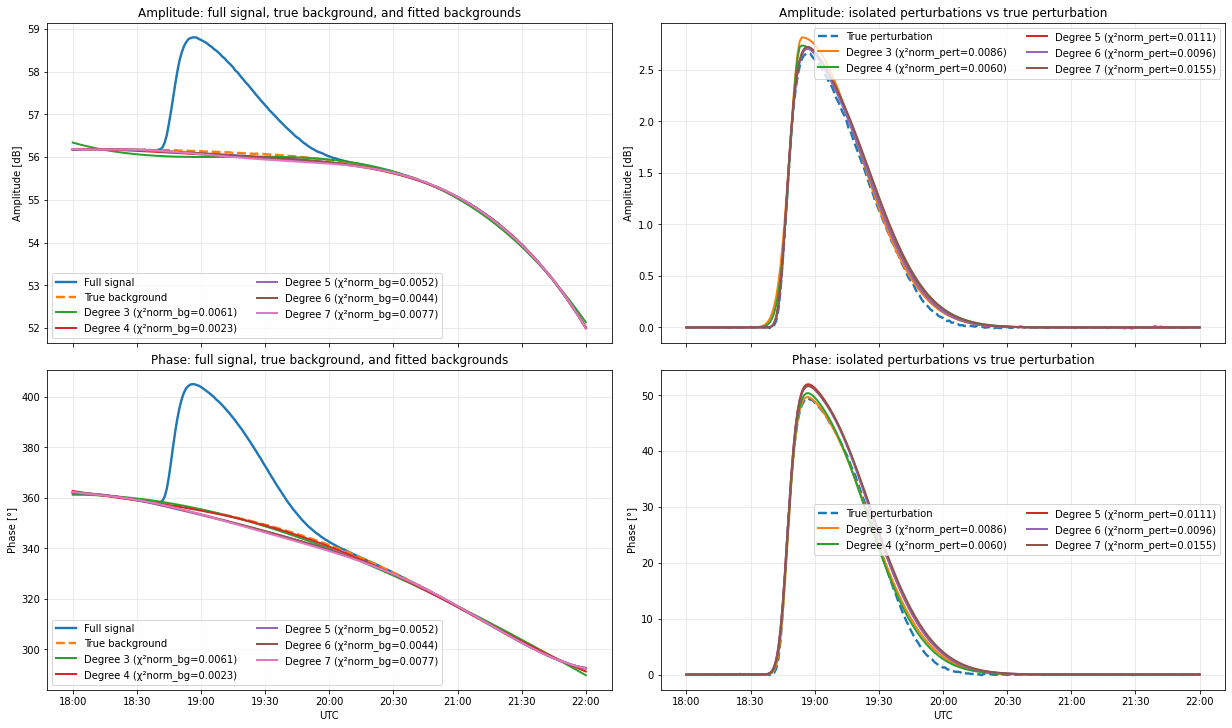

In [3]:

# ============================================================
# PLOTTING HELPERS
# ============================================================
date_fmt = mdates.DateFormatter(DATE_FORMAT)

def apply_time_axis(ax):
    ax.xaxis.set_major_formatter(date_fmt)
    ax.grid(True, alpha=PLOT_STYLE["alpha_grid"])

def legend_label_for_degree(deg, metric_name, metric_value):
    return f"Degree {deg} ({metric_name}={metric_value:.4f})"

# ============================================================
# MAIN 2x2 FIGURE
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=PLOT_STYLE["figsize_main"], sharex=True, constrained_layout=True)

# ----------------------------
# (1, 1) Amplitude background
# ----------------------------
ax = axes[0, 0]
ax.plot(time_utc, truth["A"]["full_signal"], label="Full signal", linewidth=PLOT_STYLE["lw_signal"])
ax.plot(time_utc, truth["A"]["background"], label="True background", linewidth=PLOT_STYLE["lw_true"], linestyle="--")
for deg in BG_DEGREES:
    label = legend_label_for_degree(deg, "χ²norm_bg", results_by_degree[deg]["chi2norm_bg"])
    ax.plot(time_utc, results_by_degree[deg]["A"]["background"], label=label, linewidth=PLOT_STYLE["lw_fit"])
ax.set_title("Amplitude: full signal, true background, and fitted backgrounds")
ax.set_ylabel("Amplitude [dB]")
apply_time_axis(ax)
ax.legend(ncol=2)

# ----------------------------
# (1, 2) Amplitude perturbation
# ----------------------------
ax = axes[0, 1]
ax.plot(time_utc, truth["A"]["perturbation"], label="True perturbation", linewidth=PLOT_STYLE["lw_true"], linestyle="--")
for deg in BG_DEGREES:
    label = legend_label_for_degree(deg, "χ²norm_pert", results_by_degree[deg]["chi2norm_pert"])
    ax.plot(time_utc, results_by_degree[deg]["A"]["perturbation"], label=label, linewidth=PLOT_STYLE["lw_fit"])
ax.set_title("Amplitude: isolated perturbations vs true perturbation")
ax.set_ylabel("Amplitude [dB]")
apply_time_axis(ax)
ax.legend(ncol=2)

# ----------------------------
# (2, 1) Phase background
# ----------------------------
ax = axes[1, 0]
ax.plot(time_utc, truth["phi"]["full_signal"], label="Full signal", linewidth=PLOT_STYLE["lw_signal"])
ax.plot(time_utc, truth["phi"]["background"], label="True background", linewidth=PLOT_STYLE["lw_true"], linestyle="--")
for deg in BG_DEGREES:
    label = legend_label_for_degree(deg, "χ²norm_bg", results_by_degree[deg]["chi2norm_bg"])
    ax.plot(time_utc, results_by_degree[deg]["phi"]["background"], label=label, linewidth=PLOT_STYLE["lw_fit"])
ax.set_title("Phase: full signal, true background, and fitted backgrounds")
ax.set_ylabel("Phase [°]")
ax.set_xlabel("UTC")
apply_time_axis(ax)
ax.legend(ncol=2)

# ----------------------------
# (2, 2) Phase perturbation
# ----------------------------
ax = axes[1, 1]
ax.plot(time_utc, truth["phi"]["perturbation"], label="True perturbation", linewidth=PLOT_STYLE["lw_true"], linestyle="--")
for deg in BG_DEGREES:
    label = legend_label_for_degree(deg, "χ²norm_pert", results_by_degree[deg]["chi2norm_pert"])
    ax.plot(time_utc, results_by_degree[deg]["phi"]["perturbation"], label=label, linewidth=PLOT_STYLE["lw_fit"])
ax.set_title("Phase: isolated perturbations vs true perturbation")
ax.set_ylabel("Phase [°]")
ax.set_xlabel("UTC")
apply_time_axis(ax)
ax.legend(ncol=2)

plt.show()


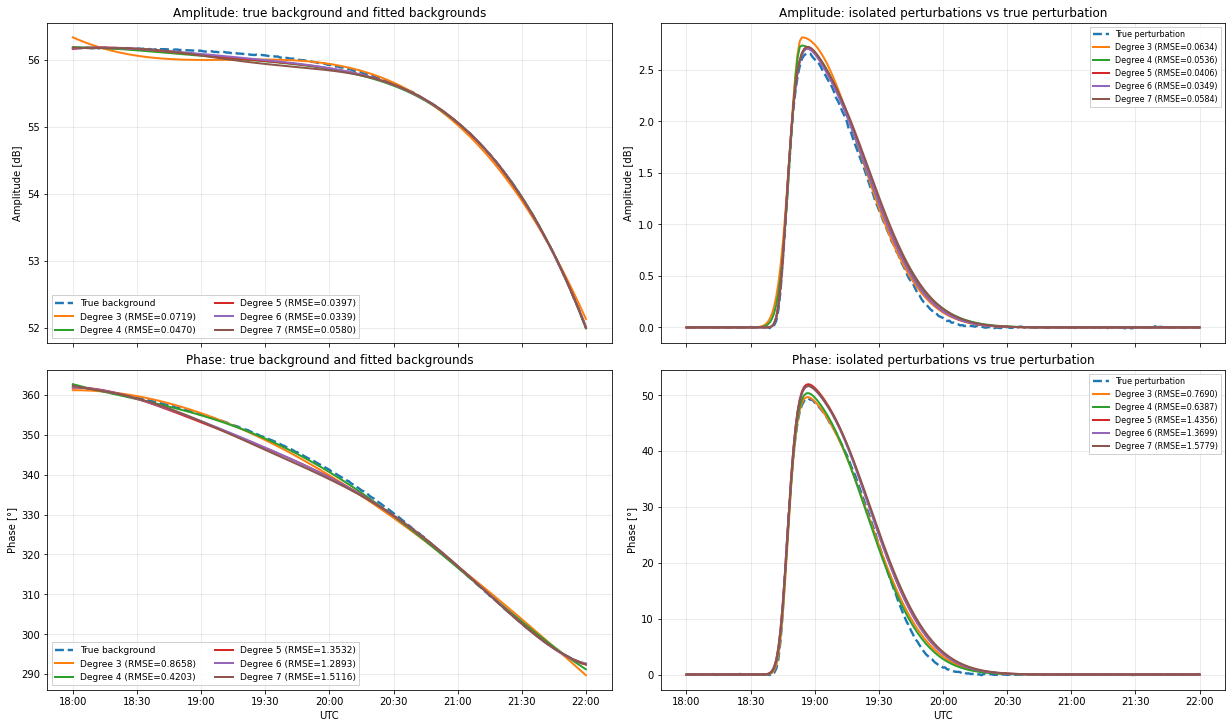

In [9]:
# ============================================================
# PLOTTING HELPERS
# ============================================================
date_fmt = mdates.DateFormatter(DATE_FORMAT)

def apply_time_axis(ax):
    ax.xaxis.set_major_formatter(date_fmt)
    ax.grid(True, alpha=PLOT_STYLE["alpha_grid"])

def legend_label_for_degree(deg, rmse_value):
    return f"Degree {deg} (RMSE={rmse_value:.4f})"

legend_kw_left = dict(
    ncol=2,
    loc="lower left",
    frameon=True,
    framealpha=0.9,
    fancybox=False,
    borderpad=0.4,
    fontsize=9
)

legend_kw_right = dict(
    loc="upper right",
    frameon=True,
    framealpha=0.9,
    fancybox=False,
    borderpad=0.4,
    fontsize=8
)

# ============================================================
# MAIN 2x2 FIGURE
# ============================================================
fig, axes = plt.subplots(
    2, 2,
    figsize=PLOT_STYLE["figsize_main"],
    sharex=True,
    constrained_layout=True
)

# ----------------------------
# (1, 1) Amplitude background
# ----------------------------
ax = axes[0, 0]
ax.plot(
    time_utc,
    truth["A"]["background"],
    label="True background",
    linewidth=PLOT_STYLE["lw_true"],
    linestyle="--"
)
for deg in BG_DEGREES:
    rmse_val = results_by_degree[deg]["component_metrics"]["A_bg"]["rmse"]
    label = legend_label_for_degree(deg, rmse_val)
    ax.plot(
        time_utc,
        results_by_degree[deg]["A"]["background"],
        label=label,
        linewidth=PLOT_STYLE["lw_fit"]
    )
ax.set_title("Amplitude: true background and fitted backgrounds")
ax.set_ylabel("Amplitude [dB]")
apply_time_axis(ax)
ax.legend(**legend_kw_left)

# ----------------------------
# (1, 2) Amplitude perturbation
# ----------------------------
ax = axes[0, 1]
ax.plot(
    time_utc,
    truth["A"]["perturbation"],
    label="True perturbation",
    linewidth=PLOT_STYLE["lw_true"],
    linestyle="--"
)
for deg in BG_DEGREES:
    rmse_val = results_by_degree[deg]["component_metrics"]["A_pert"]["rmse"]
    label = legend_label_for_degree(deg, rmse_val)
    ax.plot(
        time_utc,
        results_by_degree[deg]["A"]["perturbation"],
        label=label,
        linewidth=PLOT_STYLE["lw_fit"]
    )
ax.set_title("Amplitude: isolated perturbations vs true perturbation")
ax.set_ylabel("Amplitude [dB]")
apply_time_axis(ax)
ax.legend(**legend_kw_right)

# ----------------------------
# (2, 1) Phase background
# ----------------------------
ax = axes[1, 0]
ax.plot(
    time_utc,
    truth["phi"]["background"],
    label="True background",
    linewidth=PLOT_STYLE["lw_true"],
    linestyle="--"
)
for deg in BG_DEGREES:
    rmse_val = results_by_degree[deg]["component_metrics"]["phi_bg"]["rmse"]
    label = legend_label_for_degree(deg, rmse_val)
    ax.plot(
        time_utc,
        results_by_degree[deg]["phi"]["background"],
        label=label,
        linewidth=PLOT_STYLE["lw_fit"]
    )
ax.set_title("Phase: true background and fitted backgrounds")
ax.set_ylabel("Phase [°]")
ax.set_xlabel("UTC")
apply_time_axis(ax)
ax.legend(**legend_kw_left)

# ----------------------------
# (2, 2) Phase perturbation
# ----------------------------
ax = axes[1, 1]
ax.plot(
    time_utc,
    truth["phi"]["perturbation"],
    label="True perturbation",
    linewidth=PLOT_STYLE["lw_true"],
    linestyle="--"
)
for deg in BG_DEGREES:
    rmse_val = results_by_degree[deg]["component_metrics"]["phi_pert"]["rmse"]
    label = legend_label_for_degree(deg, rmse_val)
    ax.plot(
        time_utc,
        results_by_degree[deg]["phi"]["perturbation"],
        label=label,
        linewidth=PLOT_STYLE["lw_fit"]
    )
ax.set_title("Phase: isolated perturbations vs true perturbation")
ax.set_ylabel("Phase [°]")
ax.set_xlabel("UTC")
apply_time_axis(ax)
ax.legend(**legend_kw_right)

plt.show()

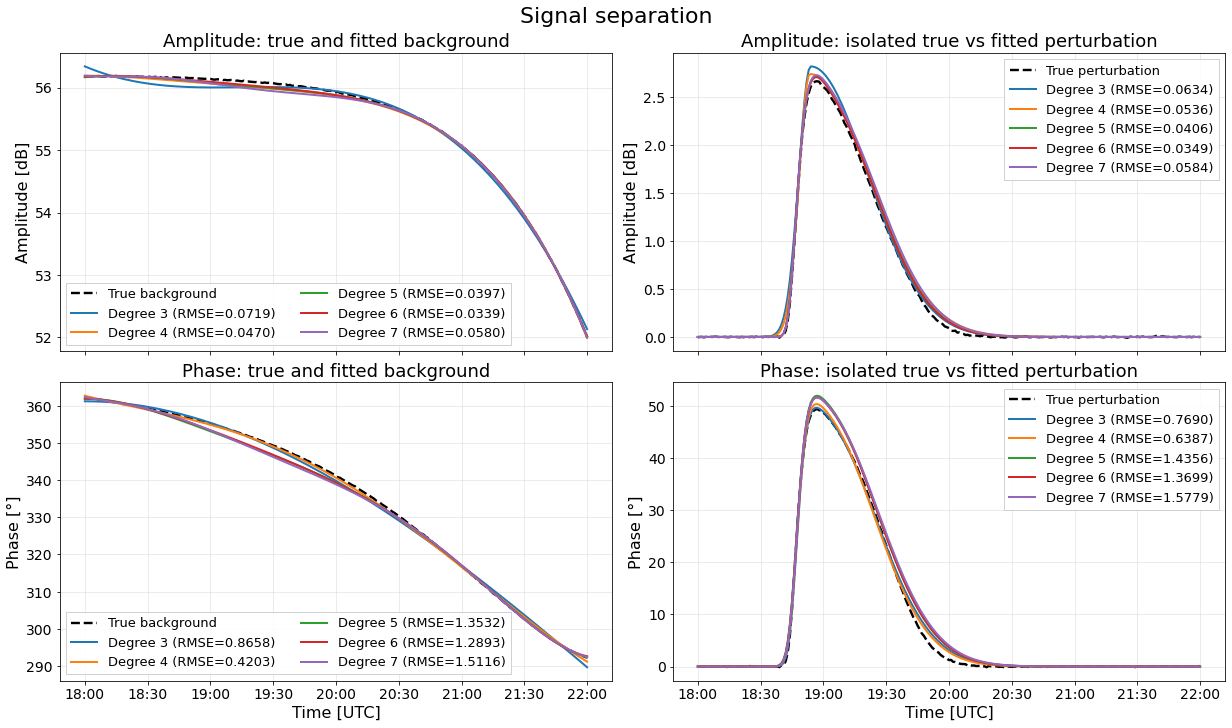

In [28]:
# ============================================================
# PLOTTING HELPERS
# ============================================================
date_fmt = mdates.DateFormatter(DATE_FORMAT)

FS_TITLE   = 18
FS_LABEL   = 16
FS_TICK    = 14
FS_LEGEND  = 13
FS_SUPER   = 22

def apply_time_axis(ax):
    ax.xaxis.set_major_formatter(date_fmt)
    ax.grid(True, alpha=PLOT_STYLE["alpha_grid"])
    ax.tick_params(axis="both", labelsize=FS_TICK)

def legend_label_for_degree(deg, rmse_value):
    return f"Degree {deg} (RMSE={rmse_value:.4f})"

legend_kw_left = dict(
    ncol=2,
    loc="lower left",
    frameon=True,
    framealpha=0.9,
    fancybox=False,
    borderpad=0.4,
    fontsize=FS_LEGEND
)

legend_kw_right = dict(
    loc="upper right",
    frameon=True,
    framealpha=0.9,
    fancybox=False,
    borderpad=0.4,
    fontsize=FS_LEGEND
)

# ============================================================
# MAIN 2x2 FIGURE
# ============================================================
fig, axes = plt.subplots(
    2, 2,
    figsize=PLOT_STYLE["figsize_main"],
    sharex=True,
    constrained_layout=True
)

fig.suptitle("Signal separation", fontsize=FS_SUPER)

# ----------------------------
# (1, 1) Amplitude background
# ----------------------------
ax = axes[0, 0]
ax.plot(
    time_utc,
    truth["A"]["background"],
    label="True background",
    linewidth=PLOT_STYLE["lw_true"],
    linestyle="--",color="black"
)
for deg in BG_DEGREES:
    rmse_val = results_by_degree[deg]["component_metrics"]["A_bg"]["rmse"]
    label = legend_label_for_degree(deg, rmse_val)
    ax.plot(
        time_utc,
        results_by_degree[deg]["A"]["background"],
        label=label,
        linewidth=PLOT_STYLE["lw_fit"]
    )
ax.set_title("Amplitude: true and fitted background", fontsize=FS_TITLE)
ax.set_ylabel("Amplitude [dB]", fontsize=FS_LABEL)
apply_time_axis(ax)
ax.legend(**legend_kw_left)

# ----------------------------
# (1, 2) Amplitude perturbation
# ----------------------------
ax = axes[0, 1]
ax.plot(
    time_utc,
    truth["A"]["perturbation"],
    label="True perturbation",
    linewidth=PLOT_STYLE["lw_true"],
    linestyle="--",color="black"
)
for deg in BG_DEGREES:
    rmse_val = results_by_degree[deg]["component_metrics"]["A_pert"]["rmse"]
    label = legend_label_for_degree(deg, rmse_val)
    ax.plot(
        time_utc,
        results_by_degree[deg]["A"]["perturbation"],
        label=label,
        linewidth=PLOT_STYLE["lw_fit"]
    )
ax.set_title("Amplitude: isolated true vs fitted perturbation", fontsize=FS_TITLE)
ax.set_ylabel("Amplitude [dB]", fontsize=FS_LABEL)
apply_time_axis(ax)
ax.legend(**legend_kw_right)

# ----------------------------
# (2, 1) Phase background
# ----------------------------
ax = axes[1, 0]
ax.plot(
    time_utc,
    truth["phi"]["background"],
    label="True background",
    linewidth=PLOT_STYLE["lw_true"],
    linestyle="--",color="black"
)
for deg in BG_DEGREES:
    rmse_val = results_by_degree[deg]["component_metrics"]["phi_bg"]["rmse"]
    label = legend_label_for_degree(deg, rmse_val)
    ax.plot(
        time_utc,
        results_by_degree[deg]["phi"]["background"],
        label=label,
        linewidth=PLOT_STYLE["lw_fit"]
    )
ax.set_title("Phase: true and fitted background", fontsize=FS_TITLE)
ax.set_ylabel("Phase [°]", fontsize=FS_LABEL)
ax.set_xlabel("Time [UTC]", fontsize=FS_LABEL)
apply_time_axis(ax)
ax.legend(**legend_kw_left)

# ----------------------------
# (2, 2) Phase perturbation
# ----------------------------
ax = axes[1, 1]
ax.plot(
    time_utc,
    truth["phi"]["perturbation"],
    label="True perturbation",
    linewidth=PLOT_STYLE["lw_true"],
    linestyle="--",color="black"
)
for deg in BG_DEGREES:
    rmse_val = results_by_degree[deg]["component_metrics"]["phi_pert"]["rmse"]
    label = legend_label_for_degree(deg, rmse_val)
    ax.plot(
        time_utc,
        results_by_degree[deg]["phi"]["perturbation"],
        label=label,
        linewidth=PLOT_STYLE["lw_fit"]
    )
ax.set_title("Phase: isolated true vs fitted perturbation", fontsize=FS_TITLE)
ax.set_ylabel("Phase [°]", fontsize=FS_LABEL)
ax.set_xlabel("Time [UTC]", fontsize=FS_LABEL)
apply_time_axis(ax)
ax.legend(**legend_kw_right)
plt.savefig("signal-separation-synthetic-data-final.pdf",bbox_inches="tight")
plt.show()

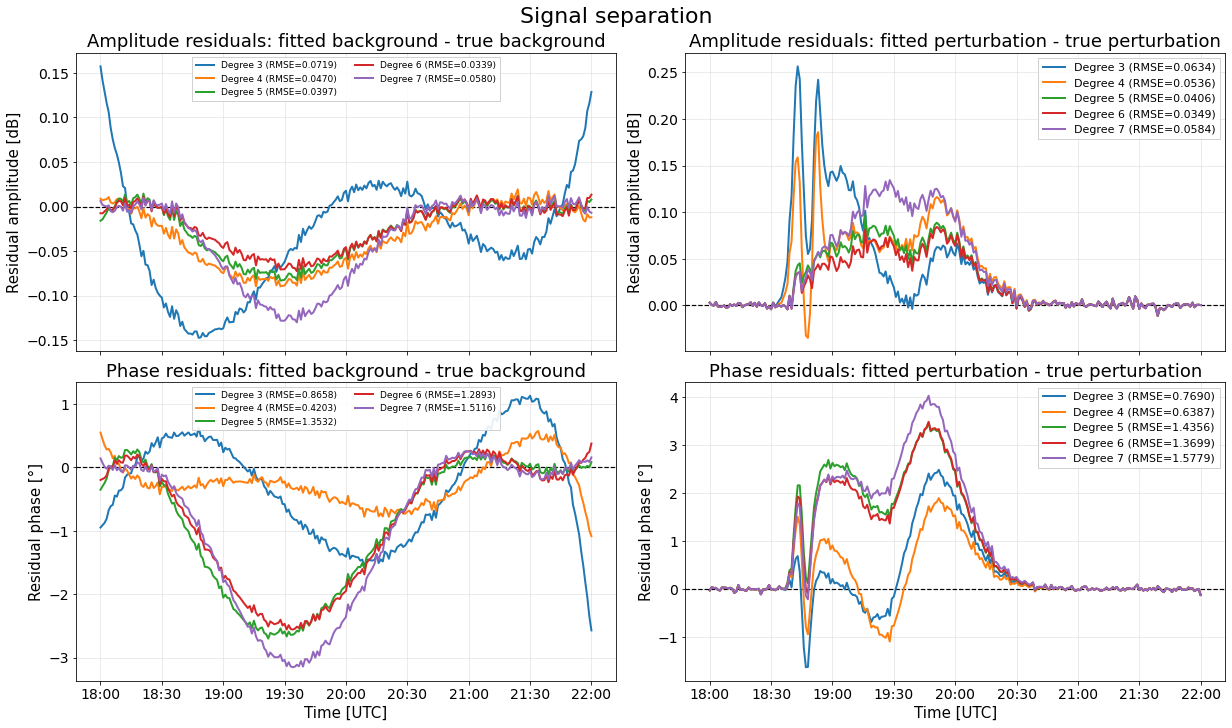

In [27]:
# ============================================================
# PLOTTING HELPERS
# ============================================================
date_fmt = mdates.DateFormatter(DATE_FORMAT)

FS_TITLE         = 18
FS_LABEL         = 15
FS_TICK          = 14
FS_SUPER         = 22
FS_LEGEND_LEFT   = 9
FS_LEGEND_RIGHT  = 11

def apply_time_axis(ax):
    ax.xaxis.set_major_formatter(date_fmt)
    ax.grid(True, alpha=PLOT_STYLE["alpha_grid"])
    ax.tick_params(axis="both", labelsize=FS_TICK)

def legend_label_for_degree(deg, rmse_value):
    return f"Degree {deg} (RMSE={rmse_value:.4f})"

legend_kw_left = dict(
    ncol=2,
    loc="upper center",
    frameon=True,
    framealpha=0.9,
    fancybox=False,
    borderpad=0.4,
    fontsize=FS_LEGEND_LEFT
)

legend_kw_right = dict(
    loc="upper right",
    frameon=True,
    framealpha=0.9,
    fancybox=False,
    borderpad=0.4,
    fontsize=FS_LEGEND_RIGHT
)

# ============================================================
# MAIN 2x2 FIGURE: RESIDUALS AGAINST TRUE COMPONENTS
# ============================================================
fig, axes = plt.subplots(
    2, 2,
    figsize=PLOT_STYLE["figsize_main"],
    sharex=True,
    constrained_layout=True
)

fig.suptitle("Signal separation", fontsize=FS_SUPER)

# ----------------------------
# (1, 1) Amplitude background residuals
# ----------------------------
ax = axes[0, 0]
ax.axhline(0.0, color="black", linestyle="--", linewidth=1.2)
for deg in BG_DEGREES:
    residual = results_by_degree[deg]["A"]["background"] - truth["A"]["background"]
    rmse_val = results_by_degree[deg]["component_metrics"]["A_bg"]["rmse"]
    label = legend_label_for_degree(deg, rmse_val)
    ax.plot(time_utc, residual, label=label, linewidth=PLOT_STYLE["lw_fit"])
ax.set_title("Amplitude residuals: fitted background - true background", fontsize=FS_TITLE)
ax.set_ylabel("Residual amplitude [dB]", fontsize=FS_LABEL)
apply_time_axis(ax)
ax.legend(**legend_kw_left)

# ----------------------------
# (1, 2) Amplitude perturbation residuals
# ----------------------------
ax = axes[0, 1]
ax.axhline(0.0, color="black", linestyle="--", linewidth=1.2)
for deg in BG_DEGREES:
    residual = results_by_degree[deg]["A"]["perturbation"] - truth["A"]["perturbation"]
    rmse_val = results_by_degree[deg]["component_metrics"]["A_pert"]["rmse"]
    label = legend_label_for_degree(deg, rmse_val)
    ax.plot(time_utc, residual, label=label, linewidth=PLOT_STYLE["lw_fit"])
ax.set_title("Amplitude residuals: fitted perturbation - true perturbation", fontsize=FS_TITLE)
ax.set_ylabel("Residual amplitude [dB]", fontsize=FS_LABEL)
apply_time_axis(ax)
ax.legend(**legend_kw_right)

# ----------------------------
# (2, 1) Phase background residuals
# ----------------------------
ax = axes[1, 0]
ax.axhline(0.0, color="black", linestyle="--", linewidth=1.2)
for deg in BG_DEGREES:
    residual = results_by_degree[deg]["phi"]["background"] - truth["phi"]["background"]
    rmse_val = results_by_degree[deg]["component_metrics"]["phi_bg"]["rmse"]
    label = legend_label_for_degree(deg, rmse_val)
    ax.plot(time_utc, residual, label=label, linewidth=PLOT_STYLE["lw_fit"])
ax.set_title("Phase residuals: fitted background - true background", fontsize=FS_TITLE)
ax.set_ylabel("Residual phase [°]", fontsize=FS_LABEL)
ax.set_xlabel("Time [UTC]", fontsize=FS_LABEL)
apply_time_axis(ax)
ax.legend(**legend_kw_left)

# ----------------------------
# (2, 2) Phase perturbation residuals
# ----------------------------
ax = axes[1, 1]
ax.axhline(0.0, color="black", linestyle="--", linewidth=1.2)
for deg in BG_DEGREES:
    residual = results_by_degree[deg]["phi"]["perturbation"] - truth["phi"]["perturbation"]
    rmse_val = results_by_degree[deg]["component_metrics"]["phi_pert"]["rmse"]
    label = legend_label_for_degree(deg, rmse_val)
    ax.plot(time_utc, residual, label=label, linewidth=PLOT_STYLE["lw_fit"])
ax.set_title("Phase residuals: fitted perturbation - true perturbation", fontsize=FS_TITLE)
ax.set_ylabel("Residual phase [°]", fontsize=FS_LABEL)
ax.set_xlabel("Time [UTC]", fontsize=FS_LABEL)
apply_time_axis(ax)
ax.legend(**legend_kw_right)
plt.savefig("signal-separation-synthetic-data-residuals-final.pdf",bbox_inches="tight")
plt.show()

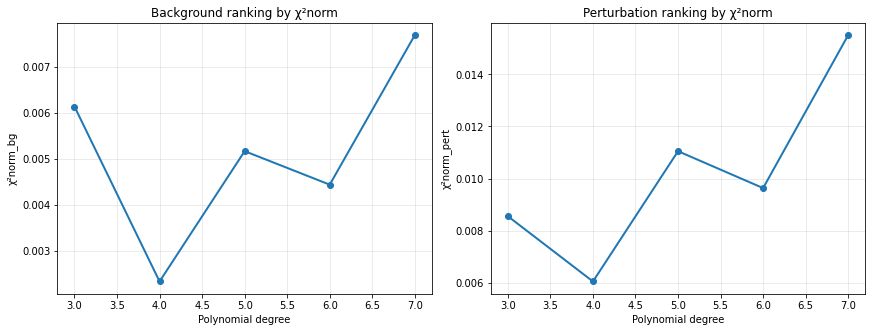

In [4]:

# ============================================================
# OPTIONAL DIAGNOSTIC: ranking by normalized chi-square
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=PLOT_STYLE["figsize_rank"], constrained_layout=True)

axes[0].plot(component_summary["degree"], component_summary["chi2norm_bg"], marker="o", linewidth=2)
axes[0].set_title("Background ranking by χ²norm")
axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("χ²norm_bg")
axes[0].grid(True, alpha=PLOT_STYLE["alpha_grid"])

axes[1].plot(component_summary["degree"], component_summary["chi2norm_pert"], marker="o", linewidth=2)
axes[1].set_title("Perturbation ranking by χ²norm")
axes[1].set_xlabel("Polynomial degree")
axes[1].set_ylabel("χ²norm_pert")
axes[1].grid(True, alpha=PLOT_STYLE["alpha_grid"])

plt.show()


In [5]:

# ============================================================
# OPTIONAL EXPORT
# Choose the criterion explicitly:
#   criterion = "bg"   -> best by chi2norm_bg
#   criterion = "pert" -> best by chi2norm_pert
# ============================================================
criterion = "bg"
output_filename = f"best_background_perturbation_separation_{criterion}.h5"

if criterion == "bg":
    deg_export = best_degree_bg
elif criterion == "pert":
    deg_export = best_degree_pert
else:
    raise ValueError("criterion debe ser 'bg' o 'pert'")

A_export = results_by_degree[deg_export]["A"]
phi_export = results_by_degree[deg_export]["phi"]

with h5py.File(output_filename, "w") as f:
    f.create_dataset("timestamps", data=np.asarray(timestamps, dtype=float))
    f.create_dataset("A_background", data=np.asarray(A_export["background"], dtype=float))
    f.create_dataset("A_perturbation", data=np.asarray(A_export["perturbation"], dtype=float))
    f.create_dataset("phi_background", data=np.asarray(phi_export["background"], dtype=float))
    f.create_dataset("phi_perturbation", data=np.asarray(phi_export["perturbation"], dtype=float))

    f.attrs["selected_degree"] = int(deg_export)
    f.attrs["selection_criterion"] = criterion
    f.attrs["chi2norm_bg"] = float(results_by_degree[deg_export]["chi2norm_bg"])
    f.attrs["chi2norm_pert"] = float(results_by_degree[deg_export]["chi2norm_pert"])
    f.attrs["model"] = "polynomial background + F3 perturbation"
    f.attrs["note"] = "Targets for χ²norm are the true synthetic background and perturbation."

print(f"Archivo guardado: {output_filename}")
print(f"Degree exported : {deg_export}")
print(f"chi2norm_bg     : {results_by_degree[deg_export]['chi2norm_bg']:.6f}")
print(f"chi2norm_pert   : {results_by_degree[deg_export]['chi2norm_pert']:.6f}")


Archivo guardado: best_background_perturbation_separation_bg.h5
Degree exported : 4
chi2norm_bg     : 0.002331
chi2norm_pert   : 0.006045
